# Distributed ML Banking Project



#### GitHub Link:https://github.com/ShouryaKumar1996/Distributed-Machine-Learning-for-Financial-Forecasting

## Section 1: Exploratory Data Analysis

# Exploratory Data Analysis (EDA) with Spark
## Distributed ML Banking Project

This notebook performs a comprehensive EDA on the **bank.csv** dataset using Apache Spark.
The dataset contains information about bank marketing campaigns and whether clients subscribed to a term deposit.

**Dataset Columns:**
- `age`, `job`, `marital`, `education`, `default`, `balance`, `housing`, `loan`
- `contact`, `day`, `month`, `duration`, `campaign`, `pdays`, `previous`, `poutcome`, `y`

## Setup and Imports

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, avg, count, sum, when, desc, upper,
    concat_ws, expr, percentile_approx
)
from pyspark.sql.types import StringType
from pyspark.sql.functions import udf

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Plot styling
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
sns.set_style('whitegrid')

print('Libraries imported successfully.')

Libraries imported successfully.


In [20]:
import os

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [2]:
spark = SparkSession.builder \
    .master('local[*]') \
    .appName('Banking_EDA') \
    .config('spark.driver.memory', '2g') \
    .getOrCreate()

spark.sparkContext.setLogLevel('WARN')
print('Spark Version:', spark.version)

Spark Version: 3.5.0


---
## Question 1: Data Loading and Basic Inspection

In [6]:
df = spark.read.csv(
    r'C:\Users\shourya\Desktop\Distributed_ML_Banking\data',
    header=True,
    inferSchema=True
)

print(f'Rows: {df.count()}')
print(f'Columns: {len(df.columns)}')
print(f'Column names: {df.columns}')

Rows: 4521
Columns: 17
Column names: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


In [7]:
# Show first 5 rows
print('First 5 rows:')
df.show(5, truncate=False)

First 5 rows:
+---+-----------+-------+---------+-------+-------+-------+----+--------+---+-----+--------+--------+-----+--------+--------+---+
|age|job        |marital|education|default|balance|housing|loan|contact |day|month|duration|campaign|pdays|previous|poutcome|y  |
+---+-----------+-------+---------+-------+-------+-------+----+--------+---+-----+--------+--------+-----+--------+--------+---+
|30 |unemployed |married|primary  |no     |1787   |no     |no  |cellular|19 |oct  |79      |1       |-1   |0       |unknown |no |
|33 |services   |married|secondary|no     |4789   |yes    |yes |cellular|11 |may  |220     |1       |339  |4       |failure |no |
|35 |management |single |tertiary |no     |1350   |yes    |no  |cellular|16 |apr  |185     |1       |330  |1       |failure |no |
|30 |management |married|tertiary |no     |1476   |yes    |yes |unknown |3  |jun  |199     |4       |-1   |0       |unknown |no |
|59 |blue-collar|married|secondary|no     |0      |yes    |no  |unknown |5  

In [8]:
# Print schema
print('Schema:')
df.printSchema()

Schema:
root
 |-- age: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- marital: string (nullable = true)
 |-- education: string (nullable = true)
 |-- default: string (nullable = true)
 |-- balance: integer (nullable = true)
 |-- housing: string (nullable = true)
 |-- loan: string (nullable = true)
 |-- contact: string (nullable = true)
 |-- day: integer (nullable = true)
 |-- month: string (nullable = true)
 |-- duration: integer (nullable = true)
 |-- campaign: integer (nullable = true)
 |-- pdays: integer (nullable = true)
 |-- previous: integer (nullable = true)
 |-- poutcome: string (nullable = true)
 |-- y: string (nullable = true)



In [9]:
# Summary statistics for numerical columns
print('Summary Statistics:')
df.describe().show()

Summary Statistics:
+-------+------------------+-------+--------+---------+-------+------------------+-------+----+--------+------------------+-----+------------------+------------------+------------------+------------------+--------+----+
|summary|               age|    job| marital|education|default|           balance|housing|loan| contact|               day|month|          duration|          campaign|             pdays|          previous|poutcome|   y|
+-------+------------------+-------+--------+---------+-------+------------------+-------+----+--------+------------------+-----+------------------+------------------+------------------+------------------+--------+----+
|  count|              4521|   4521|    4521|     4521|   4521|              4521|   4521|4521|    4521|              4521| 4521|              4521|              4521|              4521|              4521|    4521|4521|
|   mean| 41.17009511170095|   NULL|    NULL|     NULL|   NULL|1422.6578190665782|   NULL|NULL|    N

In [10]:
# Check for missing/null values
print('Missing Values per Column:')
df.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in df.columns
]).show()

Missing Values per Column:
+---+---+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
|age|job|marital|education|default|balance|housing|loan|contact|day|month|duration|campaign|pdays|previous|poutcome|  y|
+---+---+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
|  0|  0|      0|        0|      0|      0|      0|   0|      0|  0|    0|       0|       0|    0|       0|       0|  0|
+---+---+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+



---
## Question 2: Data Filtering and Column Operations

In [11]:
# Filter clients with balance > 1000
high_balance_df = df.filter(col('balance') > 1000)

print(f'Total clients: {df.count()}')
print(f'Clients with balance > 1000: {high_balance_df.count()}')
print(f'Percentage: {high_balance_df.count() / df.count() * 100:.1f}%')

high_balance_df.show(5)

Total clients: 4521
Clients with balance > 1000: 1481
Percentage: 32.8%
+---+----------+-------+---------+-------+-------+-------+----+--------+---+-----+--------+--------+-----+--------+--------+---+
|age|       job|marital|education|default|balance|housing|loan| contact|day|month|duration|campaign|pdays|previous|poutcome|  y|
+---+----------+-------+---------+-------+-------+-------+----+--------+---+-----+--------+--------+-----+--------+--------+---+
| 30|unemployed|married|  primary|     no|   1787|     no|  no|cellular| 19|  oct|      79|       1|   -1|       0| unknown| no|
| 33|  services|married|secondary|     no|   4789|    yes| yes|cellular| 11|  may|     220|       1|  339|       4| failure| no|
| 35|management| single| tertiary|     no|   1350|    yes|  no|cellular| 16|  apr|     185|       1|  330|       1| failure| no|
| 30|management|married| tertiary|     no|   1476|    yes| yes| unknown|  3|  jun|     199|       4|   -1|       0| unknown| no|
| 39|  services|married|s

In [12]:
# Create quarter column from month
df = df.withColumn(
    'quarter',
    when(col('month').isin('jan', 'feb', 'mar'), 'Q1')
    .when(col('month').isin('apr', 'may', 'jun'), 'Q2')
    .when(col('month').isin('jul', 'aug', 'sep'), 'Q3')
    .otherwise('Q4')
)

print('Month to Quarter mapping sample:')
df.select('month', 'quarter').distinct().orderBy('quarter', 'month').show(20)

print('Clients per Quarter:')
df.groupBy('quarter').count().orderBy('quarter').show()

Month to Quarter mapping sample:
+-----+-------+
|month|quarter|
+-----+-------+
|  feb|     Q1|
|  jan|     Q1|
|  mar|     Q1|
|  apr|     Q2|
|  jun|     Q2|
|  may|     Q2|
|  aug|     Q3|
|  jul|     Q3|
|  sep|     Q3|
|  dec|     Q4|
|  nov|     Q4|
|  oct|     Q4|
+-----+-------+

Clients per Quarter:
+-------+-----+
|quarter|count|
+-------+-----+
|     Q1|  419|
|     Q2| 2222|
|     Q3| 1391|
|     Q4|  489|
+-------+-----+



---
## Question 3: GroupBy and Aggregation

In [13]:
# Average balance and median age per job category
job_stats = df.groupBy('job').agg(
    avg('balance').alias('avg_balance'),
    percentile_approx('age', 0.5).alias('median_age'),
    count('*').alias('total_clients')
).orderBy(desc('avg_balance'))

print('Average Balance and Median Age per Job Category:')
job_stats.show(truncate=False)

Average Balance and Median Age per Job Category:
+-------------+------------------+----------+-------------+
|job          |avg_balance       |median_age|total_clients|
+-------------+------------------+----------+-------------+
|retired      |2319.191304347826 |59        |230          |
|housemaid    |2083.8035714285716|49        |112          |
|management   |1766.9287925696594|38        |969          |
|entrepreneur |1645.125          |41        |168          |
|student      |1543.8214285714287|26        |84           |
|unknown      |1501.7105263157894|49        |38           |
|self-employed|1392.4098360655737|40        |183          |
|technician   |1330.99609375     |38        |768          |
|admin.       |1226.73640167364  |38        |478          |
|services     |1103.9568345323742|37        |417          |
|unemployed   |1089.421875       |41        |128          |
|blue-collar  |1085.161733615222 |39        |946          |
+-------------+------------------+----------+------

In [14]:
# Total subscribed clients per marital status
marital_subscribers = df.filter(col('y') == 'yes') \
    .groupBy('marital') \
    .agg(
        count('*').alias('subscribed_count')
    ).orderBy(desc('subscribed_count'))

print('Subscribed Clients per Marital Status:')
marital_subscribers.show()

Subscribed Clients per Marital Status:
+--------+----------------+
| marital|subscribed_count|
+--------+----------------+
| married|             277|
|  single|             167|
|divorced|              77|
+--------+----------------+



---
## Question 4: UDF to Categorize Age Groups

In [15]:
# Define and apply UDF for age grouping
def age_category(age):
    if age is None:
        return 'Unknown'
    elif age < 30:
        return '<30'
    elif age <= 60:
        return '30-60'
    else:
        return '>60'

age_udf = udf(age_category, StringType())

df = df.withColumn('age_group', age_udf(col('age')))

print('Age Group Distribution:')
df.groupBy('age_group') \
  .agg(
      count('*').alias('count'),
      avg('balance').alias('avg_balance')
  ) \
  .orderBy('age_group') \
  .show()

print('Sample rows with age_group:')
df.select('age', 'age_group').show(10)

Age Group Distribution:
+---------+-----+------------------+
|age_group|count|       avg_balance|
+---------+-----+------------------+
|    30-60| 3912|1426.8755112474437|
|      <30|  482|1058.0954356846473|
|      >60|  127|2676.3543307086616|
+---------+-----+------------------+

Sample rows with age_group:
+---+---------+
|age|age_group|
+---+---------+
| 30|    30-60|
| 33|    30-60|
| 35|    30-60|
| 30|    30-60|
| 59|    30-60|
| 35|    30-60|
| 36|    30-60|
| 39|    30-60|
| 41|    30-60|
| 43|    30-60|
+---+---------+
only showing top 10 rows



---
## Question 5: Advanced Data Transformations

In [16]:
# Subscription rate by education level
subscription_rate = df.groupBy('education').agg(
    count('*').alias('total'),
    sum(when(col('y') == 'yes', 1).otherwise(0)).alias('subscribed'),
    (sum(when(col('y') == 'yes', 1).otherwise(0)) / count('*') * 100)
        .alias('subscription_rate_%')
).orderBy(desc('subscription_rate_%'))

print('Subscription Rate by Education Level:')
subscription_rate.show()

Subscription Rate by Education Level:
+---------+-----+----------+-------------------+
|education|total|subscribed|subscription_rate_%|
+---------+-----+----------+-------------------+
| tertiary| 1350|       193| 14.296296296296296|
|secondary| 2306|       245| 10.624457935819601|
|  unknown|  187|        19|  10.16042780748663|
|  primary|  678|        64|   9.43952802359882|
+---------+-----+----------+-------------------+



In [17]:
# Top 3 professions with highest default rate
default_rate = df.groupBy('job').agg(
    count('*').alias('total'),
    sum(when(col('default') == 'yes', 1).otherwise(0)).alias('defaulted'),
    (sum(when(col('default') == 'yes', 1).otherwise(0)) / count('*') * 100)
        .alias('default_rate_%')
).orderBy(desc('default_rate_%'))

print('Top 3 Professions with Highest Loan Default Rate:')
default_rate.show(3)

Top 3 Professions with Highest Loan Default Rate:
+-------------+-----+---------+-----------------+
|          job|total|defaulted|   default_rate_%|
+-------------+-----+---------+-----------------+
| entrepreneur|  168|        7|4.166666666666666|
|   unemployed|  128|        3|          2.34375|
|self-employed|  183|        4|2.185792349726776|
+-------------+-----+---------+-----------------+
only showing top 3 rows



---
## Question 6: String Manipulation and Date Functions

In [18]:
# Concatenate job and marital into new column
df = df.withColumn(
    'job_marital',
    concat_ws('_', col('job'), col('marital'))
)

# Convert contact to uppercase
df = df.withColumn(
    'contact_upper',
    upper(col('contact'))
)

print('String Manipulation Results:')
df.select('job', 'marital', 'job_marital', 'contact', 'contact_upper') \
  .show(10, truncate=False)

String Manipulation Results:
+-------------+-------+---------------------+--------+-------------+
|job          |marital|job_marital          |contact |contact_upper|
+-------------+-------+---------------------+--------+-------------+
|unemployed   |married|unemployed_married   |cellular|CELLULAR     |
|services     |married|services_married     |cellular|CELLULAR     |
|management   |single |management_single    |cellular|CELLULAR     |
|management   |married|management_married   |unknown |UNKNOWN      |
|blue-collar  |married|blue-collar_married  |unknown |UNKNOWN      |
|management   |single |management_single    |cellular|CELLULAR     |
|self-employed|married|self-employed_married|cellular|CELLULAR     |
|technician   |married|technician_married   |cellular|CELLULAR     |
|entrepreneur |married|entrepreneur_married |unknown |UNKNOWN      |
|services     |married|services_married     |cellular|CELLULAR     |
+-------------+-------+---------------------+--------+-------------+
only 

---
## Question 7: Data Visualization

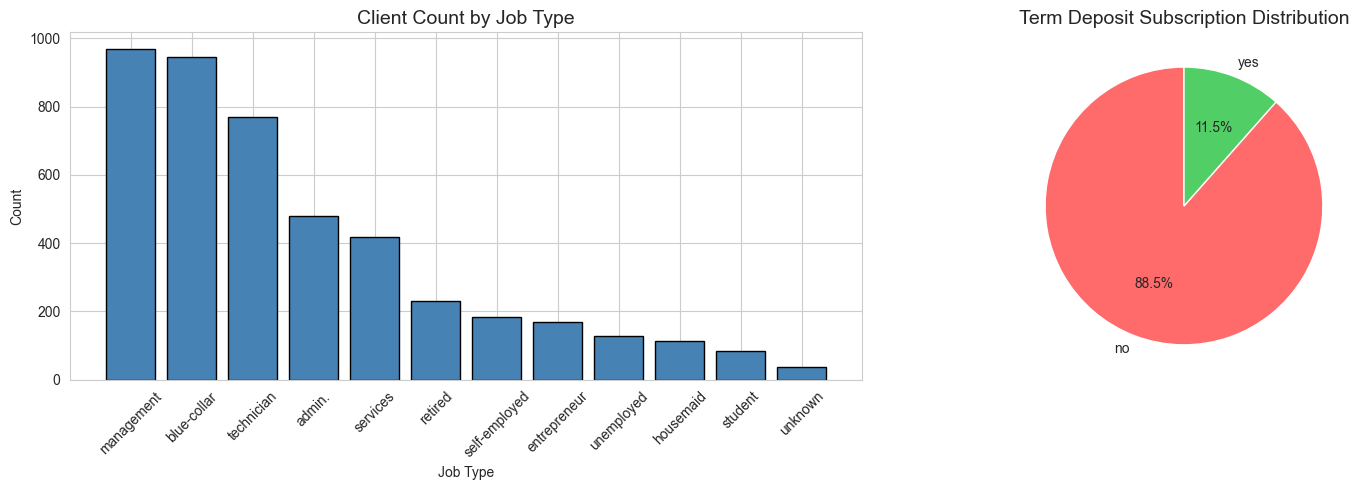

Plot saved.


In [21]:
# Convert to Pandas for visualization
job_counts_pd = df.groupBy('job').count().orderBy(desc('count')).toPandas()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar plot - Client count by job
axes[0].bar(job_counts_pd['job'], job_counts_pd['count'], color='steelblue', edgecolor='black')
axes[0].set_title('Client Count by Job Type')
axes[0].set_xlabel('Job Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Subscription distribution
sub_pd = df.groupBy('y').count().toPandas()
axes[1].pie(sub_pd['count'], labels=sub_pd['y'], autopct='%1.1f%%',
            colors=['#ff6b6b', '#51cf66'], startangle=90)
axes[1].set_title('Term Deposit Subscription Distribution')

plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, "eda_plots_1.png"),
    dpi=150,
    bbox_inches='tight'
)
plt.show()
print('Plot saved.')

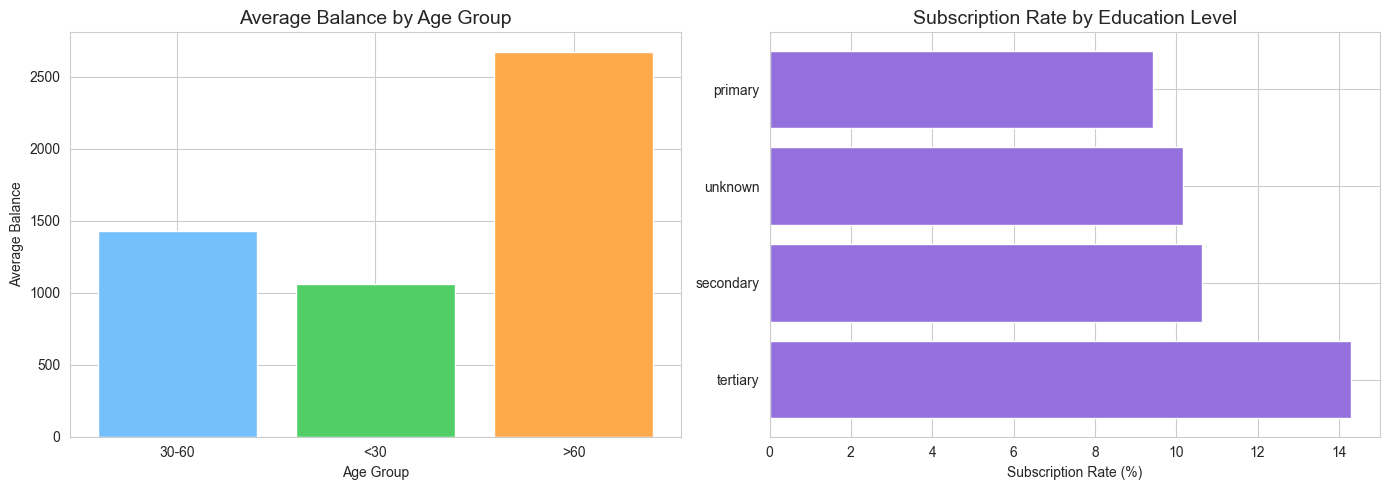

In [22]:
# Balance distribution by age group
age_balance_pd = df.groupBy('age_group') \
    .agg(avg('balance').alias('avg_balance')) \
    .orderBy('age_group') \
    .toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(age_balance_pd['age_group'], age_balance_pd['avg_balance'],
            color=['#74c0fc', '#51cf66', '#ffa94d'])
axes[0].set_title('Average Balance by Age Group')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Average Balance')

# Education subscription rate
edu_sub_pd = subscription_rate.toPandas()
axes[1].barh(edu_sub_pd['education'], edu_sub_pd['subscription_rate_%'], color='mediumpurple')
axes[1].set_title('Subscription Rate by Education Level')
axes[1].set_xlabel('Subscription Rate (%)')

plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, "eda_plots_2.png"),
    dpi=150,
    bbox_inches='tight'
)
plt.show()

---
## Question 8: Complex Queries for Insights

In [23]:
# Month with highest contacts and success rate
month_analysis = df.groupBy('month').agg(
    count('*').alias('total_contacts'),
    sum(when(col('y') == 'yes', 1).otherwise(0)).alias('subscribed'),
    (sum(when(col('y') == 'yes', 1).otherwise(0)) / count('*') * 100)
        .alias('success_rate_%')
).orderBy(desc('total_contacts'))

print('Monthly Contact Analysis:')
month_analysis.show()

best_month = month_analysis.first()
print(f'\nMonth with most contacts: {best_month["month"]} ({best_month["total_contacts"]} contacts, {best_month["success_rate_%"]:.1f}% success rate)')

Monthly Contact Analysis:
+-----+--------------+----------+------------------+
|month|total_contacts|subscribed|    success_rate_%|
+-----+--------------+----------+------------------+
|  may|          1398|        93| 6.652360515021459|
|  jul|           706|        61| 8.640226628895183|
|  aug|           633|        79|12.480252764612953|
|  jun|           531|        55|10.357815442561206|
|  nov|           389|        39|10.025706940874036|
|  apr|           293|        56|19.112627986348123|
|  feb|           222|        38|17.117117117117118|
|  jan|           148|        16| 10.81081081081081|
|  oct|            80|        37|             46.25|
|  sep|            52|        17| 32.69230769230769|
|  mar|            49|        21|42.857142857142854|
|  dec|            20|         9|              45.0|
+-----+--------------+----------+------------------+


Month with most contacts: may (1398 contacts, 6.7% success rate)


Average Contact Duration by Subscription Status:
+---+--------------------+------------+
|  y|avg_duration_seconds|client_count|
+---+--------------------+------------+
| no|            226.3475|        4000|
|yes|   552.7428023032629|         521|
+---+--------------------+------------+



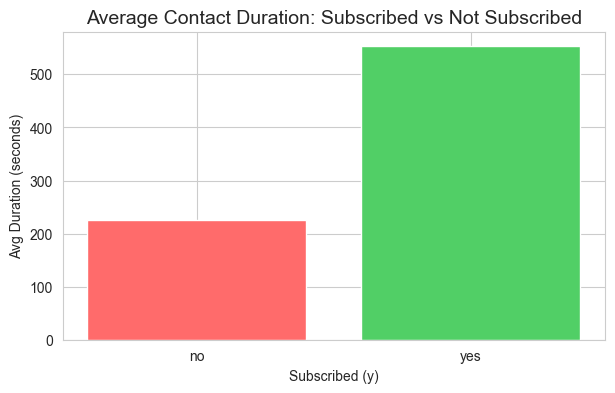

In [25]:
# Average contact duration: subscribed vs not subscribed
duration_analysis = df.groupBy('y').agg(
    avg('duration').alias('avg_duration_seconds'),
    count('*').alias('client_count')
)

print('Average Contact Duration by Subscription Status:')
duration_analysis.show()

dur_pd = duration_analysis.toPandas()
plt.figure(figsize=(7, 4))
plt.bar(dur_pd['y'], dur_pd['avg_duration_seconds'], color=['#ff6b6b', '#51cf66'])
plt.title('Average Contact Duration: Subscribed vs Not Subscribed')
plt.xlabel('Subscribed (y)')
plt.ylabel('Avg Duration (seconds)')
plt.savefig(
    os.path.join(OUTPUT_DIR, "eda_plots_3.png"),
    dpi=150,
    bbox_inches='tight'
)
plt.show()

---
## Question 9: Correlation Between Age and Balance

In [26]:
corr_value = df.stat.corr('age', 'balance')
print(f'Pearson Correlation between Age and Balance: {corr_value:.4f}')
print()
if abs(corr_value) < 0.1:
    print('Interpretation: Very weak or negligible correlation.')
elif abs(corr_value) < 0.3:
    print('Interpretation: Weak positive correlation.')
elif abs(corr_value) < 0.5:
    print('Interpretation: Moderate positive correlation.')
else:
    print('Interpretation: Strong positive correlation.')

Pearson Correlation between Age and Balance: 0.0838

Interpretation: Very weak or negligible correlation.


---
## Question 10: Exploring Loan Defaults

Credit Default Distribution:
  default  count
0      no   4445
1     yes     76
  no: 4445 (98.3%)
  yes: 76 (1.7%)


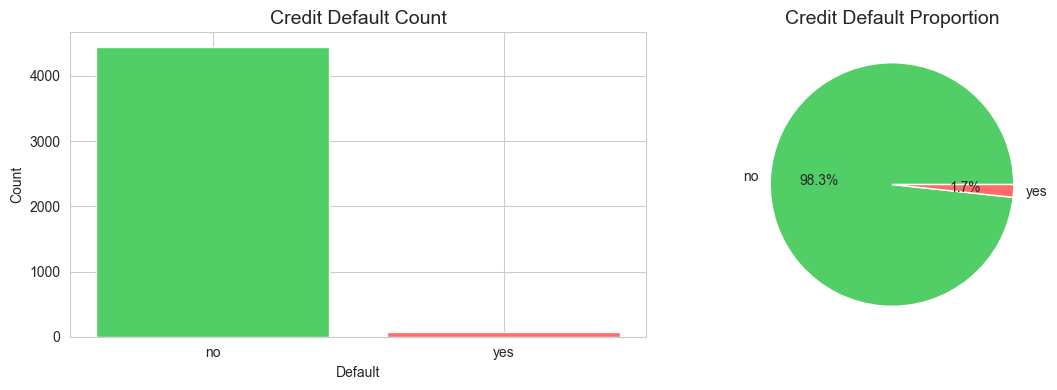

In [28]:
# Default distribution
default_dist = df.groupBy('default').agg(
    count('*').alias('count')
).toPandas()

print('Credit Default Distribution:')
print(default_dist)
total = default_dist['count'].sum()
for _, row in default_dist.iterrows():
    print(f"  {row['default']}: {row['count']} ({row['count']/total*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(default_dist['default'], default_dist['count'],
            color=['#51cf66', '#ff6b6b'])
axes[0].set_title('Credit Default Count')
axes[0].set_xlabel('Default')
axes[0].set_ylabel('Count')

axes[1].pie(default_dist['count'], labels=default_dist['default'],
            autopct='%1.1f%%', colors=['#51cf66', '#ff6b6b'])
axes[1].set_title('Credit Default Proportion')

plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, "eda_plots_4.png"),
    dpi=150,
    bbox_inches='tight'
)
plt.show()

---
## Question 11: Contact Method Analysis

Contact Method Success Rate Analysis:
+---------+--------------+----------+-----------------+
|  contact|total_contacts|subscribed|   success_rate_%|
+---------+--------------+----------+-----------------+
|telephone|           301|        44|14.61794019933555|
| cellular|          2896|       416| 14.3646408839779|
|  unknown|          1324|        61|4.607250755287009|
+---------+--------------+----------+-----------------+



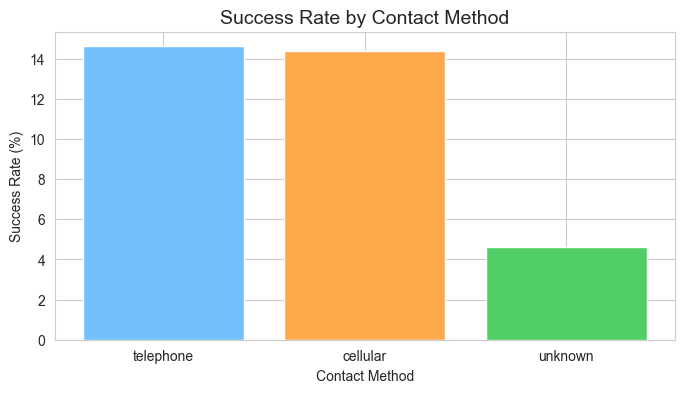

In [30]:
contact_success = df.groupBy('contact').agg(
    count('*').alias('total_contacts'),
    sum(when(col('y') == 'yes', 1).otherwise(0)).alias('subscribed'),
    (sum(when(col('y') == 'yes', 1).otherwise(0)) / count('*') * 100)
        .alias('success_rate_%')
).orderBy(desc('success_rate_%'))

print('Contact Method Success Rate Analysis:')
contact_success.show()

contact_pd = contact_success.toPandas()
plt.figure(figsize=(8, 4))
plt.bar(contact_pd['contact'], contact_pd['success_rate_%'],
        color=['#74c0fc', '#ffa94d', '#51cf66'])
plt.title('Success Rate by Contact Method')
plt.xlabel('Contact Method')
plt.ylabel('Success Rate (%)')
plt.savefig(
    os.path.join(OUTPUT_DIR, "eda_plots_5.png"),
    dpi=150,
    bbox_inches='tight'
)
plt.show()

---
## Question 12: Data Processing with Spark SQL

In [31]:
# Create temporary view
df.createOrReplaceTempView('bank_data')
print('Temporary view bank_data created.')

Temporary view bank_data created.


In [32]:
# Average balance by age group using Spark SQL
print('Average Balance by Age Group (Spark SQL):')
spark.sql("""
    SELECT age_group,
           COUNT(*) AS total_clients,
           ROUND(AVG(balance), 2) AS avg_balance,
           ROUND(AVG(age), 1) AS avg_age
    FROM bank_data
    GROUP BY age_group
    ORDER BY avg_balance DESC
""").show()

Average Balance by Age Group (Spark SQL):
+---------+-------------+-----------+-------+
|age_group|total_clients|avg_balance|avg_age|
+---------+-------------+-----------+-------+
|      >60|          127|    2676.35|   69.8|
|    30-60|         3912|    1426.88|   42.0|
|      <30|          482|     1058.1|   26.7|
+---------+-------------+-----------+-------+



In [33]:
# Most common job types using Spark SQL
print('Most Common Job Types (Spark SQL):')
spark.sql("""
    SELECT job,
           COUNT(*) AS total_clients,
           ROUND(AVG(balance), 2) AS avg_balance,
           ROUND(SUM(CASE WHEN y = 'yes' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS subscription_rate
    FROM bank_data
    GROUP BY job
    ORDER BY total_clients DESC
""").show()

Most Common Job Types (Spark SQL):
+-------------+-------------+-----------+-----------------+
|          job|total_clients|avg_balance|subscription_rate|
+-------------+-------------+-----------+-----------------+
|   management|          969|    1766.93|            13.52|
|  blue-collar|          946|    1085.16|             7.29|
|   technician|          768|     1331.0|            10.81|
|       admin.|          478|    1226.74|            12.13|
|     services|          417|    1103.96|             9.11|
|      retired|          230|    2319.19|            23.48|
|self-employed|          183|    1392.41|            10.93|
| entrepreneur|          168|    1645.13|             8.93|
|   unemployed|          128|    1089.42|            10.16|
|    housemaid|          112|     2083.8|            12.50|
|      student|           84|    1543.82|            22.62|
|      unknown|           38|    1501.71|            18.42|
+-------------+-------------+-----------+-----------------+



In [34]:
# Summary: Key EDA Insights
print('='*60)
print('KEY EDA INSIGHTS SUMMARY')
print('='*60)
print(f'Total records: {df.count()}')
print(f'Total features: {len(df.columns)}')
print(f'Subscription rate: {df.filter(col("y")=="yes").count()/df.count()*100:.1f}%')
print(f'Age-Balance correlation: {corr_value:.4f}')
print(f'Clients with balance > 1000: {high_balance_df.count()} ({high_balance_df.count()/df.count()*100:.1f}%)')
print('='*60)

KEY EDA INSIGHTS SUMMARY
Total records: 4521
Total features: 21
Subscription rate: 11.5%
Age-Balance correlation: 0.0838
Clients with balance > 1000: 1481 (32.8%)


In [35]:
spark.stop()
print('Spark session stopped.')

Spark session stopped.


## Section 2: Data Parallelism

# Efficient Data Handling through Data Parallelism
## Distributed ML Banking Project

This notebook demonstrates data parallelism using Apache Spark on the `bank.csv` dataset.

**Key Concepts Covered:**
- Dataset partitioning strategies for parallel processing
- Parallel aggregations and analysis
- Model training on partitioned data
- Resource monitoring during processing
- Parallel task management and scheduling

## Setup and Imports

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, avg, count, desc, when, sum, stddev
)
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator

import psutil
import time
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from concurrent.futures import ThreadPoolExecutor

plt.rcParams['figure.figsize'] = (12, 5)
print('Imports successful.')

Imports successful.


In [3]:
spark = SparkSession.builder \
    .master('local[*]') \
    .appName('Data_Parallelism') \
    .config('spark.driver.memory', '2g') \
    .config('spark.sql.adaptive.enabled', 'true') \
    .getOrCreate()

spark.sparkContext.setLogLevel('WARN')
num_cores = spark.sparkContext.defaultParallelism
print(f'Spark Version: {spark.version}')
print(f'Available cores: {num_cores}')

Spark Version: 3.5.0
Available cores: 8


---
## Section 1: Data Preparation and Partitioning

In [4]:
# Load dataset
df = spark.read.csv(
    r'C:\Users\shourya\Desktop\Distributed_ML_Banking\data',
    header=True,
    inferSchema=True
)

print(f'Dataset loaded: {df.count()} rows, {len(df.columns)} columns')
df.show(5)

Dataset loaded: 4521 rows, 17 columns
+---+-----------+-------+---------+-------+-------+-------+----+--------+---+-----+--------+--------+-----+--------+--------+---+
|age|        job|marital|education|default|balance|housing|loan| contact|day|month|duration|campaign|pdays|previous|poutcome|  y|
+---+-----------+-------+---------+-------+-------+-------+----+--------+---+-----+--------+--------+-----+--------+--------+---+
| 30| unemployed|married|  primary|     no|   1787|     no|  no|cellular| 19|  oct|      79|       1|   -1|       0| unknown| no|
| 33|   services|married|secondary|     no|   4789|    yes| yes|cellular| 11|  may|     220|       1|  339|       4| failure| no|
| 35| management| single| tertiary|     no|   1350|    yes|  no|cellular| 16|  apr|     185|       1|  330|       1| failure| no|
| 30| management|married| tertiary|     no|   1476|    yes| yes| unknown|  3|  jun|     199|       4|   -1|       0| unknown| no|
| 59|blue-collar|married|secondary|     no|      0| 

In [7]:
default_partitions = df.rdd.getNumPartitions()
print(f"Default partitions: {default_partitions}")

partitioned_df = df.repartition(4)

print(f"Partitions after repartition(4): {partitioned_df.rdd.getNumPartitions()}")
print(f"Total rows: {partitioned_df.count()}")

print("\nPartitioning strategy: Round-Robin (repartition)")
print("Reason: Ensures balanced data distribution across all partitions")
print("for efficient parallel processing.")

Default partitions: 1
Partitions after repartition(4): 4
Total rows: 4521

Partitioning strategy: Round-Robin (repartition)
Reason: Ensures balanced data distribution across all partitions
for efficient parallel processing.


In [8]:
import builtins

partition_sizes = partitioned_df.rdd.mapPartitionsWithIndex(
    lambda idx, iterator: [(idx, builtins.sum(1 for _ in iterator))]
).collect()

print(partition_sizes)

[(0, 1130), (1, 1131), (2, 1130), (3, 1130)]


In [12]:
import os

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

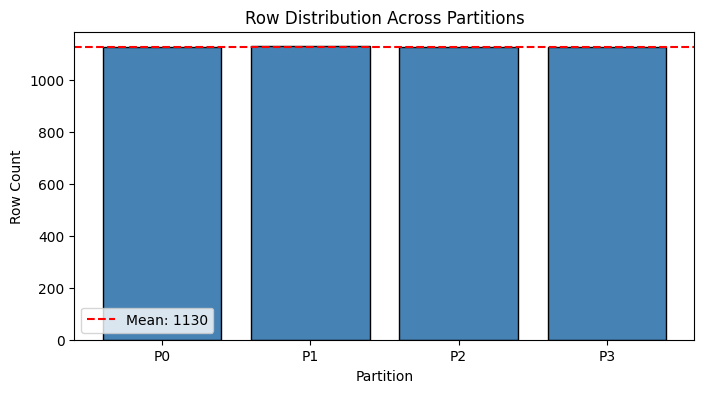

In [13]:
# Visualize partition distribution
pid_labels = [f'P{p}' for p, _ in partition_sizes]
pid_counts = [s for _, s in partition_sizes]

plt.figure(figsize=(8, 4))
plt.bar(pid_labels, pid_counts, color='steelblue', edgecolor='black')
import builtins

mean_count = builtins.sum(pid_counts) / len(pid_counts)

plt.axhline(
    y=mean_count,
    color='red',
    linestyle='--',
    label=f'Mean: {mean_count:.0f}'
)
plt.title('Row Distribution Across Partitions')
plt.xlabel('Partition')
plt.ylabel('Row Count')
plt.legend()
plt.savefig(
    os.path.join(OUTPUT_DIR, "partition_dist.png"),
    dpi=150,
    bbox_inches='tight'
)
plt.show()

---
## Section 2: Data Analysis and Processing in Parallel

In [14]:
# Parallel computation: Average balance per job category
# Spark distributes this across all 4 partitions simultaneously

start_time = time.time()

job_balance = (
    partitioned_df
    .groupBy('job')
    .agg(
        avg('balance').alias('avg_balance'),
        count('*').alias('client_count'),
        stddev('balance').alias('std_balance')
    )
    .orderBy(desc('avg_balance'))
)

job_balance.show(truncate=False)

elapsed = time.time() - start_time
print(f'Computation completed in {elapsed:.2f} seconds across 4 partitions')

+-------------+------------------+------------+------------------+
|job          |avg_balance       |client_count|std_balance       |
+-------------+------------------+------------+------------------+
|retired      |2319.191304347826 |230         |5846.379888960141 |
|housemaid    |2083.8035714285716|112         |4603.83664686076  |
|management   |1766.9287925696594|969         |3267.7330773742196|
|entrepreneur |1645.125          |168         |4441.303620172447 |
|student      |1543.8214285714287|84          |2579.8866705319238|
|unknown      |1501.7105263157894|38          |1957.2582575922956|
|self-employed|1392.4098360655737|183         |2479.6409992088907|
|technician   |1330.99609375     |768         |2630.253389518714 |
|admin.       |1226.73640167364  |478         |2370.1191279963887|
|services     |1103.9568345323742|417         |2445.239976239857 |
|unemployed   |1089.421875       |128         |1692.2676284003926|
|blue-collar  |1085.161733615222 |946         |2040.2182195388

In [15]:
# Show execution plan to confirm parallel processing
print('Physical Execution Plan (confirms parallel processing):')
job_balance.explain()

Physical Execution Plan (confirms parallel processing):
== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Sort [avg_balance#234 DESC NULLS LAST], true, 0
   +- Exchange rangepartitioning(avg_balance#234 DESC NULLS LAST, 200), ENSURE_REQUIREMENTS, [plan_id=219]
      +- HashAggregate(keys=[job#18], functions=[avg(balance#22), count(1), stddev(cast(balance#22 as double))])
         +- Exchange hashpartitioning(job#18, 200), ENSURE_REQUIREMENTS, [plan_id=216]
            +- HashAggregate(keys=[job#18], functions=[partial_avg(balance#22), partial_count(1), partial_stddev(cast(balance#22 as double))])
               +- Exchange RoundRobinPartitioning(4), REPARTITION_BY_NUM, [plan_id=211]
                  +- FileScan csv [job#18,balance#22] Batched: false, DataFilters: [], Format: CSV, Location: InMemoryFileIndex(1 paths)[file:/C:/Users/shourya/Desktop/Distributed_ML_Banking/data], PartitionFilters: [], PushedFilters: [], ReadSchema: struct<job:string,balance:int>




Top 5 Age Groups with Highest Average Balance (Loan Holders):
+---------+------------------+------------+
|age_group|       avg_balance|loan_holders|
+---------+------------------+------------+
|    45-54| 1202.562874251497|         167|
|    55-64|1139.5833333333333|          84|
|    25-34| 823.0739130434782|         230|
|    18-24| 792.4444444444445|           9|
|    35-44| 700.3383084577115|         201|
+---------+------------------+------------+



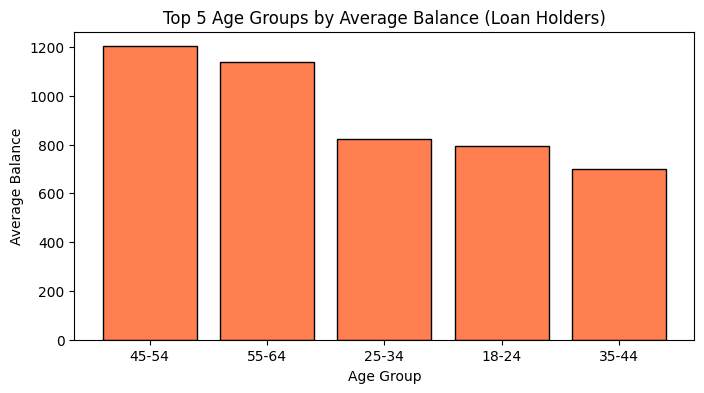

In [17]:
# Top 5 age groups with highest average balance (loan amounts)
# Methodology: Group by age brackets, compute average balance,
# filter loan holders, rank by balance

age_df = partitioned_df.withColumn(
    'age_group',
    when(col('age') < 25, '18-24')
    .when(col('age') < 35, '25-34')
    .when(col('age') < 45, '35-44')
    .when(col('age') < 55, '45-54')
    .when(col('age') < 65, '55-64')
    .otherwise('65+')
)

# Top 5 age groups by average balance among loan holders
top_age_loan = (
    age_df.filter(col('loan') == 'yes')
    .groupBy('age_group')
    .agg(
        avg('balance').alias('avg_balance'),
        count('*').alias('loan_holders')
    )
    .orderBy(desc('avg_balance'))
    .limit(5)
)

print('Top 5 Age Groups with Highest Average Balance (Loan Holders):')
top_age_loan.show()

top_pd = top_age_loan.toPandas()
plt.figure(figsize=(8, 4))
plt.bar(top_pd['age_group'], top_pd['avg_balance'], color='coral', edgecolor='black')
plt.title('Top 5 Age Groups by Average Balance (Loan Holders)')
plt.xlabel('Age Group')
plt.ylabel('Average Balance')
plt.savefig(
    os.path.join(OUTPUT_DIR, "parallelism_age_balance.png"),
    dpi=150,
    bbox_inches='tight'
)
plt.show()

---
## Section 3: Model Training on Partitioned Data

In [18]:
# Model selection: Random Forest Classifier
# Reason: Naturally parallelizable — each tree trained independently,
# ideal for distributed Spark execution across partitions.
# Also handles class imbalance and non-linear feature interactions well.

categorical_cols = [
    'job', 'marital', 'education', 'default',
    'housing', 'loan', 'contact', 'month', 'poutcome'
]
numerical_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

indexers = [
    StringIndexer(inputCol=c, outputCol=c+'_index', handleInvalid='keep')
    for c in categorical_cols
]
encoders = [
    OneHotEncoder(inputCol=c+'_index', outputCol=c+'_vec')
    for c in categorical_cols
]
label_indexer = StringIndexer(inputCol='y', outputCol='label')
feature_cols = [c+'_vec' for c in categorical_cols] + numerical_cols
assembler = VectorAssembler(inputCols=feature_cols, outputCol='features')

print('Feature pipeline defined.')

Feature pipeline defined.


In [19]:
# Split using partitioned data (distributed across 4 partitions)
train_df, test_df = partitioned_df.randomSplit([0.8, 0.2], seed=42)

print(f'Training set: {train_df.count()} rows across {train_df.rdd.getNumPartitions()} partitions')
print(f'Test set: {test_df.count()} rows across {test_df.rdd.getNumPartitions()} partitions')
print()
print('Note: Spark trains on each partition in parallel, then aggregates results.')
print('Challenge: Data skew can cause unequal partition processing times.')
print('Solution: Used repartition(4) to ensure balanced partition sizes.')

Training set: 3657 rows across 4 partitions
Test set: 864 rows across 4 partitions

Note: Spark trains on each partition in parallel, then aggregates results.
Challenge: Data skew can cause unequal partition processing times.
Solution: Used repartition(4) to ensure balanced partition sizes.


In [20]:
# Build and train pipeline
rf = RandomForestClassifier(
    featuresCol='features',
    labelCol='label',
    numTrees=50,
    maxDepth=5,
    seed=42
)

pipeline = Pipeline(stages=indexers + encoders + [label_indexer, assembler, rf])

start = time.time()
model = pipeline.fit(train_df)
train_time = time.time() - start

predictions = model.transform(test_df)
evaluator = BinaryClassificationEvaluator(labelCol='label')
auc = evaluator.evaluate(predictions)

print(f'Model trained in {train_time:.2f} seconds on partitioned data')
print(f'AUC: {auc:.4f}')

Model trained in 10.43 seconds on partitioned data
AUC: 0.8672


---
## Section 4: Resource Monitoring and Management

In [21]:
# Monitor CPU and memory during data processing
cpu_readings = []
mem_readings = []
timestamps = []

def monitor_resources(duration=5, interval=0.5):
    start = time.time()
    while time.time() - start < duration:
        cpu_readings.append(psutil.cpu_percent(interval=None))
        mem_readings.append(psutil.virtual_memory().percent)
        timestamps.append(time.time() - start)
        time.sleep(interval)

# Run a heavy Spark job while monitoring
with ThreadPoolExecutor(max_workers=2) as executor:
    monitor_future = executor.submit(monitor_resources, 8, 0.5)
    spark_future = executor.submit(
        lambda: partitioned_df.groupBy('job', 'education', 'marital')
                               .agg(avg('balance'), count('*'))
                               .collect()
    )
    spark_future.result()
    monitor_future.result()

print(f'CPU Usage — Avg: {np.mean(cpu_readings):.1f}%, Max: {np.max(cpu_readings):.1f}%')
print(f'Memory Usage — Avg: {np.mean(mem_readings):.1f}%, Max: {np.max(mem_readings):.1f}%')

CPU Usage — Avg: 21.2%, Max: 65.9%
Memory Usage — Avg: 64.5%, Max: 64.5%


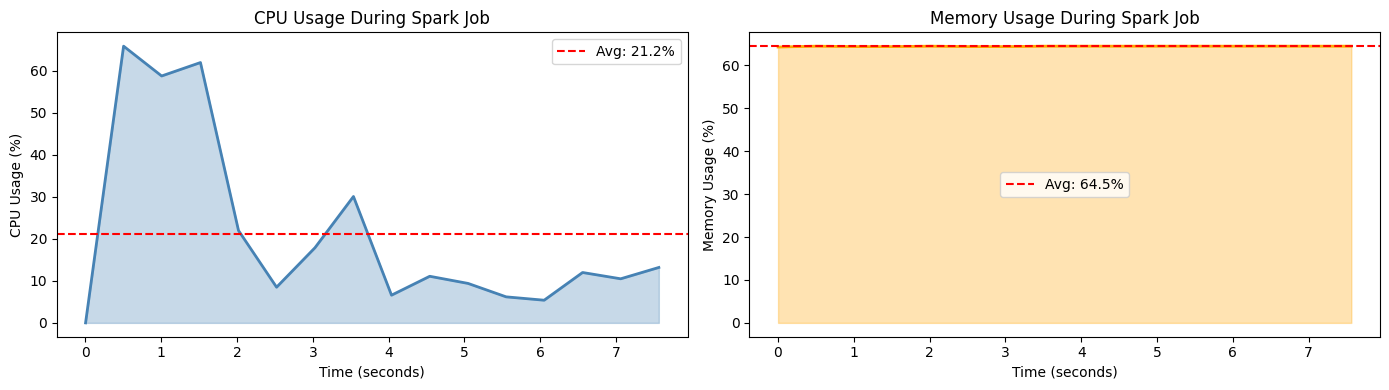

Observation: CPU spikes during Spark shuffles (groupBy operations).
Memory remains stable due to lazy evaluation and partition-level processing.


In [23]:
# Plot resource usage
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(timestamps, cpu_readings, color='steelblue', linewidth=2)
axes[0].fill_between(timestamps, cpu_readings, alpha=0.3, color='steelblue')
axes[0].set_title('CPU Usage During Spark Job')
axes[0].set_xlabel('Time (seconds)')
axes[0].set_ylabel('CPU Usage (%)')
axes[0].axhline(y=np.mean(cpu_readings), color='red', linestyle='--',
                label=f'Avg: {np.mean(cpu_readings):.1f}%')
axes[0].legend()

axes[1].plot(timestamps, mem_readings, color='orange', linewidth=2)
axes[1].fill_between(timestamps, mem_readings, alpha=0.3, color='orange')
axes[1].set_title('Memory Usage During Spark Job')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Memory Usage (%)')
axes[1].axhline(y=np.mean(mem_readings), color='red', linestyle='--',
                label=f'Avg: {np.mean(mem_readings):.1f}%')
axes[1].legend()

plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR, "parallelism_resource_usage.png"),
    dpi=150,
    bbox_inches='tight'
)

plt.show()

print('Observation: CPU spikes during Spark shuffles (groupBy operations).')
print('Memory remains stable due to lazy evaluation and partition-level processing.')

---
## Section 5: Task Management and Scheduling

In [24]:
# Manage multiple parallel preprocessing tasks
# Strategy: Define tasks as lazy Spark transformations, trigger in parallel

print('Running multiple parallel preprocessing tasks...')

# Task 1: Job count per category
task1 = partitioned_df.groupBy('job').count()

# Task 2: Education count per category
task2 = partitioned_df.groupBy('education').count()

# Task 3: Marital status count
task3 = partitioned_df.groupBy('marital').count()

# Task 4: Monthly subscription analysis
task4 = partitioned_df.groupBy('month').agg(
    count('*').alias('total'),
    sum(when(col('y') == 'yes', 1).otherwise(0)).alias('subscribed')
)

# Execute tasks in parallel using ThreadPoolExecutor
tasks = [task1, task2, task3, task4]
task_names = ['Job Distribution', 'Education Distribution',
              'Marital Distribution', 'Monthly Subscription']

start = time.time()

def run_task(args):
    name, task = args
    t0 = time.time()
    result = task.collect()
    return name, len(result), time.time() - t0

with ThreadPoolExecutor(max_workers=4) as executor:
    results = list(executor.map(run_task, zip(task_names, tasks)))

total_time = time.time() - start

print(f'\nAll tasks completed in {total_time:.2f} seconds')
print(f'{"Task":<30} {"Rows":>6} {"Time":>8}')
print('-'*46)
for name, rows, t in results:
    print(f'{name:<30} {rows:>6} {t:>7.2f}s')

Running multiple parallel preprocessing tasks...

All tasks completed in 1.28 seconds
Task                             Rows     Time
----------------------------------------------
Job Distribution                   12    0.98s
Education Distribution              4    1.02s
Marital Distribution                3    0.98s
Monthly Subscription               12    1.27s


In [25]:
# Show results of each task
print('Task 1 — Job Distribution:')
task1.orderBy(desc('count')).show()

print('Task 2 — Education Distribution:')
task2.orderBy(desc('count')).show()

print('Task 3 — Marital Status Distribution:')
task3.orderBy(desc('count')).show()

print('Task 4 — Monthly Subscription Analysis:')
task4.orderBy(desc('total')).show()

Task 1 — Job Distribution:
+-------------+-----+
|          job|count|
+-------------+-----+
|   management|  969|
|  blue-collar|  946|
|   technician|  768|
|       admin.|  478|
|     services|  417|
|      retired|  230|
|self-employed|  183|
| entrepreneur|  168|
|   unemployed|  128|
|    housemaid|  112|
|      student|   84|
|      unknown|   38|
+-------------+-----+

Task 2 — Education Distribution:
+---------+-----+
|education|count|
+---------+-----+
|secondary| 2306|
| tertiary| 1350|
|  primary|  678|
|  unknown|  187|
+---------+-----+

Task 3 — Marital Status Distribution:
+--------+-----+
| marital|count|
+--------+-----+
| married| 2797|
|  single| 1196|
|divorced|  528|
+--------+-----+

Task 4 — Monthly Subscription Analysis:
+-----+-----+----------+
|month|total|subscribed|
+-----+-----+----------+
|  may| 1398|        93|
|  jul|  706|        61|
|  aug|  633|        79|
|  jun|  531|        55|
|  nov|  389|        39|
|  apr|  293|        56|
|  feb|  222|      

In [26]:
# Execution plan showing parallel processing
print('Execution Plan for Parallel Task 1 (Job Distribution):')
task1.explain()

print('\nSummary of Partitioning & Parallelism:')
print(f'  Dataset partitions: {partitioned_df.rdd.getNumPartitions()}')
print(f'  Available CPU cores: {spark.sparkContext.defaultParallelism}')
print(f'  Tasks ran concurrently: 4')
print(f'  Total parallel execution time: {total_time:.2f}s')

Execution Plan for Parallel Task 1 (Job Distribution):
== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=true
+- == Final Plan ==
   *(2) HashAggregate(keys=[job#18], functions=[count(1)])
   +- AQEShuffleRead coalesced
      +- ShuffleQueryStage 1
         +- Exchange hashpartitioning(job#18, 200), ENSURE_REQUIREMENTS, [plan_id=2721]
            +- *(1) HashAggregate(keys=[job#18], functions=[partial_count(1)])
               +- ShuffleQueryStage 0
                  +- Exchange RoundRobinPartitioning(4), REPARTITION_BY_NUM, [plan_id=2602]
                     +- FileScan csv [job#18] Batched: false, DataFilters: [], Format: CSV, Location: InMemoryFileIndex(1 paths)[file:/C:/Users/shourya/Desktop/Distributed_ML_Banking/data], PartitionFilters: [], PushedFilters: [], ReadSchema: struct<job:string>
+- == Initial Plan ==
   HashAggregate(keys=[job#18], functions=[count(1)])
   +- Exchange hashpartitioning(job#18, 200), ENSURE_REQUIREMENTS, [plan_id=2611]
      +- HashAggregate(keys=[job#1

In [27]:
spark.stop()
print('Spark session stopped.')

Spark session stopped.


## Section 3: Machine Learning with Spark ML

# Predictive Modeling for Banking Trends
## Machine Learning with Spark ML

**Objective:** Build and evaluate machine learning models to predict whether a bank client will subscribe to a term deposit (column `y`) using the `bank.csv` dataset.

**Approach:**
- Logistic Regression and Decision Tree Classifier are trained and compared
- Feature engineering via StringIndexer, OneHotEncoder, and VectorAssembler
- Hyperparameter tuning using CrossValidator and ParamGridBuilder
- Feature importance analysis

## Setup and Imports

In [28]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, count, isnan

from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    StringIndexer, OneHotEncoder, VectorAssembler
)
from pyspark.ml.classification import (
    LogisticRegression, DecisionTreeClassifier, RandomForestClassifier
)
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator, MulticlassClassificationEvaluator
)
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams['figure.figsize'] = (10, 5)
print('Imports successful.')

Imports successful.


In [29]:
spark = SparkSession.builder \
    .master('local[*]') \
    .appName('Banking_ML') \
    .config('spark.driver.memory', '2g') \
    .getOrCreate()

spark.sparkContext.setLogLevel('WARN')
print('Spark Version:', spark.version)

Spark Version: 3.5.0


---
## Section 1: Data Loading and Initial Exploration

In [31]:
df = spark.read.csv(
    r'C:\Users\shourya\Desktop\Distributed_ML_Banking\data',
    header=True,
    inferSchema=True
)

print(f'Rows: {df.count()}')
print(f'Columns: {len(df.columns)}')
df.show(5)
df.printSchema()

Rows: 4521
Columns: 17
+---+-----------+-------+---------+-------+-------+-------+----+--------+---+-----+--------+--------+-----+--------+--------+---+
|age|        job|marital|education|default|balance|housing|loan| contact|day|month|duration|campaign|pdays|previous|poutcome|  y|
+---+-----------+-------+---------+-------+-------+-------+----+--------+---+-----+--------+--------+-----+--------+--------+---+
| 30| unemployed|married|  primary|     no|   1787|     no|  no|cellular| 19|  oct|      79|       1|   -1|       0| unknown| no|
| 33|   services|married|secondary|     no|   4789|    yes| yes|cellular| 11|  may|     220|       1|  339|       4| failure| no|
| 35| management| single| tertiary|     no|   1350|    yes|  no|cellular| 16|  apr|     185|       1|  330|       1| failure| no|
| 30| management|married| tertiary|     no|   1476|    yes| yes| unknown|  3|  jun|     199|       4|   -1|       0| unknown| no|
| 59|blue-collar|married|secondary|     no|      0|    yes|  no| un

In [32]:
# Summary statistics
df.describe().show()

# Target variable distribution
print('Target Variable Distribution:')
df.groupBy('y').count().show()

+-------+------------------+-------+--------+---------+-------+------------------+-------+----+--------+------------------+-----+------------------+------------------+------------------+------------------+--------+----+
|summary|               age|    job| marital|education|default|           balance|housing|loan| contact|               day|month|          duration|          campaign|             pdays|          previous|poutcome|   y|
+-------+------------------+-------+--------+---------+-------+------------------+-------+----+--------+------------------+-----+------------------+------------------+------------------+------------------+--------+----+
|  count|              4521|   4521|    4521|     4521|   4521|              4521|   4521|4521|    4521|              4521| 4521|              4521|              4521|              4521|              4521|    4521|4521|
|   mean| 41.17009511170095|   NULL|    NULL|     NULL|   NULL|1422.6578190665782|   NULL|NULL|    NULL|15.9152842291528

---
## Section 2: Data Preprocessing

In [33]:
# Check for missing/null values
print('Missing Values Check:')
df.select([
    count(when(col(c).isNull() | isnan(c), c)).alias(c)
    for c in df.columns
]).show()
print('No missing values found in the dataset.')

Missing Values Check:
+---+---+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
|age|job|marital|education|default|balance|housing|loan|contact|day|month|duration|campaign|pdays|previous|poutcome|  y|
+---+---+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+
|  0|  0|      0|        0|      0|      0|      0|   0|      0|  0|    0|       0|       0|    0|       0|       0|  0|
+---+---+-------+---------+-------+-------+-------+----+-------+---+-----+--------+--------+-----+--------+--------+---+

No missing values found in the dataset.


In [34]:
# Outlier removal using IQR method
def remove_outliers(dataframe, column):
    q1, q3 = dataframe.approxQuantile(column, [0.25, 0.75], 0.01)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    before = dataframe.count()
    filtered = dataframe.filter((col(column) >= lower) & (col(column) <= upper))
    after = filtered.count()
    print(f'{column}: removed {before - after} outliers (Q1={q1}, Q3={q3}, IQR={iqr:.1f}, range=[{lower:.1f}, {upper:.1f}])')
    return filtered

print('Outlier Removal (IQR Method):')
print(f'Before: {df.count()} rows')

df_clean = df
for col_name in ['balance', 'age', 'duration', 'campaign']:
    df_clean = remove_outliers(df_clean, col_name)

print(f'\nAfter outlier removal: {df_clean.count()} rows')
print(f'Rows removed: {df.count() - df_clean.count()}')

Outlier Removal (IQR Method):
Before: 4521 rows
balance: removed 530 outliers (Q1=71.0, Q3=1427.0, IQR=1356.0, range=[-1963.0, 3461.0])
age: removed 38 outliers (Q1=33.0, Q3=48.0, IQR=15.0, range=[10.5, 70.5])
duration: removed 302 outliers (Q1=100.0, Q3=321.0, IQR=221.0, range=[-231.5, 652.5])
campaign: removed 259 outliers (Q1=1.0, Q3=3.0, IQR=2.0, range=[-2.0, 6.0])

After outlier removal: 3392 rows
Rows removed: 1129


---
## Section 3: Feature Engineering and Data Transformation

In [35]:
# Define feature columns
categorical_cols = [
    'job', 'marital', 'education', 'default',
    'housing', 'loan', 'contact', 'month', 'poutcome'
]

numerical_cols = [
    'age', 'balance', 'day', 'duration',
    'campaign', 'pdays', 'previous'
]

print(f'Categorical features ({len(categorical_cols)}): {categorical_cols}')
print(f'Numerical features ({len(numerical_cols)}): {numerical_cols}')

Categorical features (9): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']
Numerical features (7): ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


In [36]:
# Label indexer for target variable
label_indexer = StringIndexer(
    inputCol='y',
    outputCol='label'
)

# StringIndexers for categorical columns
indexers = [
    StringIndexer(
        inputCol=c,
        outputCol=c + '_index',
        handleInvalid='keep'
    )
    for c in categorical_cols
]

# OneHotEncoders
encoders = [
    OneHotEncoder(
        inputCol=c + '_index',
        outputCol=c + '_vec'
    )
    for c in categorical_cols
]

# Feature vector assembler
feature_cols = [c + '_vec' for c in categorical_cols] + numerical_cols

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol='features'
)

print(f'Total feature columns: {len(feature_cols)}')
print('Feature pipeline stages created.')

Total feature columns: 16
Feature pipeline stages created.


In [37]:
# Train/test split
train_df, test_df = df_clean.randomSplit([0.8, 0.2], seed=42)

print(f'Training set: {train_df.count()} rows')
print(f'Test set: {test_df.count()} rows')
print(f'Train ratio: {train_df.count() / df_clean.count() * 100:.1f}%')

Training set: 2763 rows
Test set: 629 rows
Train ratio: 81.5%


In [38]:
# Build preprocessing pipeline and transform data
preprocessing_pipeline = Pipeline(
    stages=indexers + encoders + [label_indexer, assembler]
)

pipeline_model = preprocessing_pipeline.fit(train_df)
train_prepared = pipeline_model.transform(train_df)
test_prepared = pipeline_model.transform(test_df)

print('Preprocessing pipeline fitted and data transformed.')
train_prepared.select('label', 'features').show(5, truncate=True)

Preprocessing pipeline fitted and data transformed.
+-----+--------------------+
|label|            features|
+-----+--------------------+
|  1.0|(51,[10,13,17,19,...|
|  1.0|(51,[10,13,15,19,...|
|  0.0|(51,[10,13,15,19,...|
|  1.0|(51,[10,13,15,19,...|
|  0.0|(51,[10,13,15,19,...|
+-----+--------------------+
only showing top 5 rows



---
## Section 4: Model Training and Selection

In [39]:
# Evaluators
binary_evaluator = BinaryClassificationEvaluator(labelCol='label')
accuracy_evaluator = MulticlassClassificationEvaluator(
    labelCol='label', predictionCol='prediction', metricName='accuracy'
)
f1_evaluator = MulticlassClassificationEvaluator(
    labelCol='label', predictionCol='prediction', metricName='f1'
)

def evaluate_model(predictions, model_name):
    auc = binary_evaluator.evaluate(predictions)
    accuracy = accuracy_evaluator.evaluate(predictions)
    f1 = f1_evaluator.evaluate(predictions)
    print(f'\n{model_name} Results:')
    print(f'  AUC:      {auc:.4f}')
    print(f'  Accuracy: {accuracy:.4f} ({accuracy*100:.1f}%)')
    print(f'  F1 Score: {f1:.4f}')
    return auc, accuracy, f1

In [40]:
# Model 1: Logistic Regression
# Chosen for: interpretability, fast training, good baseline for binary classification
lr = LogisticRegression(
    featuresCol='features',
    labelCol='label',
    maxIter=100
)

lr_model = lr.fit(train_prepared)
lr_predictions = lr_model.transform(test_prepared)

print('Logistic Regression trained.')
lr_predictions.select('label', 'prediction', 'probability').show(10, truncate=False)
lr_auc, lr_acc, lr_f1 = evaluate_model(lr_predictions, 'Logistic Regression')

Logistic Regression trained.
+-----+----------+-----------------------------------------+
|label|prediction|probability                              |
+-----+----------+-----------------------------------------+
|0.0  |0.0       |[0.9467085748931209,0.05329142510687912] |
|0.0  |1.0       |[0.24439379896833902,0.755606201031661]  |
|0.0  |0.0       |[0.8220527854287495,0.1779472145712505]  |
|1.0  |1.0       |[0.35228240093578644,0.6477175990642136] |
|0.0  |0.0       |[0.9582198170866314,0.0417801829133686]  |
|0.0  |0.0       |[0.9427487632911687,0.057251236708831255]|
|0.0  |0.0       |[0.9182526463625443,0.08174735363745567] |
|0.0  |0.0       |[0.9752631751532191,0.024736824846780858]|
|1.0  |0.0       |[0.521265016034064,0.47873498396593595]  |
|0.0  |1.0       |[0.036239519673226084,0.9637604803267739]|
+-----+----------+-----------------------------------------+
only showing top 10 rows


Logistic Regression Results:
  AUC:      0.8728
  Accuracy: 0.9014 (90.1%)
  F1 Score: 0.8

In [41]:
# Model 2: Decision Tree Classifier
# Chosen for: handles non-linear relationships, interpretable rules, feature importance
dt = DecisionTreeClassifier(
    featuresCol='features',
    labelCol='label',
    maxDepth=5
)

dt_model = dt.fit(train_prepared)
dt_predictions = dt_model.transform(test_prepared)

print('Decision Tree trained.')
dt_auc, dt_acc, dt_f1 = evaluate_model(dt_predictions, 'Decision Tree')

Decision Tree trained.

Decision Tree Results:
  AUC:      0.4834
  Accuracy: 0.9078 (90.8%)
  F1 Score: 0.8879


In [42]:
# Model 3: Random Forest
# Chosen for: ensemble method, reduces overfitting, best for tabular data
rf = RandomForestClassifier(
    featuresCol='features',
    labelCol='label',
    numTrees=50,
    maxDepth=5,
    seed=42
)

rf_model = rf.fit(train_prepared)
rf_predictions = rf_model.transform(test_prepared)

print('Random Forest trained.')
rf_auc, rf_acc, rf_f1 = evaluate_model(rf_predictions, 'Random Forest')

Random Forest trained.

Random Forest Results:
  AUC:      0.8682
  Accuracy: 0.9189 (91.9%)
  F1 Score: 0.8900


In [43]:
# Model comparison
print('\n' + '='*60)
print('MODEL COMPARISON')
print('='*60)
print(f'{"Model":<25} {"AUC":>8} {"Accuracy":>10} {"F1 Score":>10}')
print('-'*60)
print(f'{"Logistic Regression":<25} {lr_auc:>8.4f} {lr_acc:>10.4f} {lr_f1:>10.4f}')
print(f'{"Decision Tree":<25} {dt_auc:>8.4f} {dt_acc:>10.4f} {dt_f1:>10.4f}')
print(f'{"Random Forest":<25} {rf_auc:>8.4f} {rf_acc:>10.4f} {rf_f1:>10.4f}')
print('='*60)


MODEL COMPARISON
Model                          AUC   Accuracy   F1 Score
------------------------------------------------------------
Logistic Regression         0.8728     0.9014     0.8866
Decision Tree               0.4834     0.9078     0.8879
Random Forest               0.8682     0.9189     0.8900


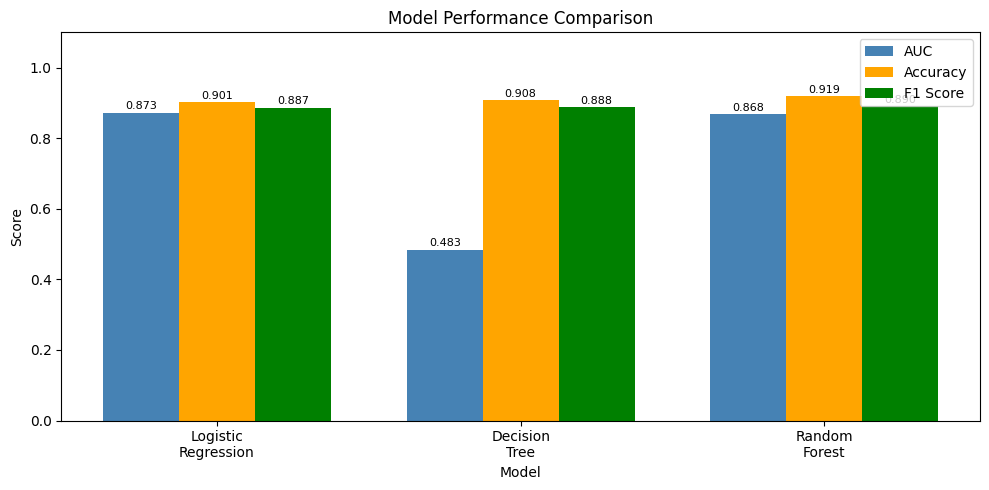

In [45]:
# Visualization: Model comparison
models = ['Logistic\nRegression', 'Decision\nTree', 'Random\nForest']
aucs = [lr_auc, dt_auc, rf_auc]
accs = [lr_acc, dt_acc, rf_acc]
f1s = [lr_f1, dt_f1, rf_f1]

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width, aucs, width, label='AUC', color='steelblue')
ax.bar(x, accs, width, label='Accuracy', color='orange')
ax.bar(x + width, f1s, width, label='F1 Score', color='green')

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0, 1.1)

for i, (auc, acc, f1) in enumerate(zip(aucs, accs, f1s)):
    ax.text(i - width, auc + 0.01, f'{auc:.3f}', ha='center', fontsize=8)
    ax.text(i, acc + 0.01, f'{acc:.3f}', ha='center', fontsize=8)
    ax.text(i + width, f1 + 0.01, f'{f1:.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, "model_comp.png"),
    dpi=150,
    bbox_inches='tight'
)
plt.show()

---
## Section 5: Model Evaluation

In [46]:
# Detailed evaluation of best model (Random Forest)
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

print('Detailed Evaluation - Random Forest (Best Model):')
for metric in ['accuracy', 'f1', 'weightedPrecision', 'weightedRecall']:
    eval_metric = MulticlassClassificationEvaluator(
        labelCol='label',
        predictionCol='prediction',
        metricName=metric
    )
    val = eval_metric.evaluate(rf_predictions)
    print(f'  {metric}: {val:.4f}')

print(f'  AUC-ROC: {rf_auc:.4f}')

Detailed Evaluation - Random Forest (Best Model):
  accuracy: 0.9189
  f1: 0.8900
  weightedPrecision: 0.9155
  weightedRecall: 0.9189
  AUC-ROC: 0.8682


In [47]:
# Confusion matrix
conf_matrix = rf_predictions.groupBy('label', 'prediction').count().toPandas()
print('Confusion Matrix (Random Forest):')
print(conf_matrix.pivot(index='label', columns='prediction', values='count').fillna(0))

Confusion Matrix (Random Forest):
prediction  0.0  1.0
label               
0.0         571    1
1.0          50    7


---
## Section 6: Hyperparameter Tuning

In [54]:
# Hyperparameter tuning for Random Forest
print('Running CrossValidator with ParamGridBuilder for Random Forest...')
print('This may take a few minutes.')

paramGrid = (
    ParamGridBuilder()
    .addGrid(rf.numTrees, [20, 50, 100])
    .addGrid(rf.maxDepth, [5, 10, 15])
    .addGrid(rf.maxBins, [32, 64])
    .build()
)

print(f'Total parameter combinations to try: {len(paramGrid)}')

crossval = CrossValidator(
    estimator=rf,
    estimatorParamMaps=paramGrid,
    evaluator=binary_evaluator,
    numFolds=3,
    seed=42
)

cv_model = crossval.fit(train_prepared)

cv_predictions = cv_model.transform(test_prepared)

cv_auc = binary_evaluator.evaluate(cv_predictions)
cv_acc = accuracy_evaluator.evaluate(cv_predictions)

print('\nCross-Validated Random Forest:')
print(f'  AUC: {cv_auc:.4f}')
print(f'  Accuracy: {cv_acc:.4f}')
print(f'  Improvement over baseline RF: {(cv_auc - rf_auc)*100:.2f}% AUC')

# Best parameters
best_rf = cv_model.bestModel

print('\nBest Parameters:')
print(f'  numTrees: {best_rf.getNumTrees}')
print(f'  maxDepth: {best_rf.getOrDefault("maxDepth")}')
print(f'  maxBins: {best_rf.getOrDefault("maxBins")}')

Running CrossValidator with ParamGridBuilder for Random Forest...
This may take a few minutes.
Total parameter combinations to try: 18

Cross-Validated Random Forest:
  AUC: 0.8841
  Accuracy: 0.9173
  Improvement over baseline RF: 1.59% AUC

Best Parameters:
  numTrees: 100
  maxDepth: 10
  maxBins: 32


---
## Section 7: Advanced Analysis — Feature Importances

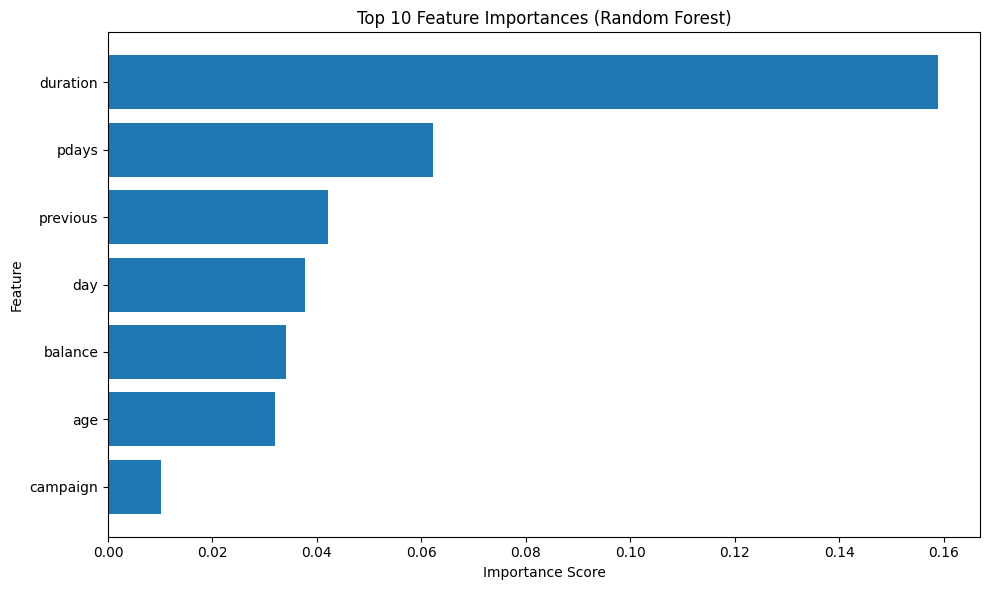


Most Influential Features:
 Feature  Importance
duration    0.159017
   pdays    0.062131
previous    0.042059
     day    0.037739
 balance    0.033983
     age    0.032065
campaign    0.010236


In [60]:
# Top Feature Importance Visualization

plt.figure(figsize=(10, 6))

top_features = importance_df.head(10)

plt.barh(
    top_features['Feature'][::-1],
    top_features['Importance'][::-1]
)

plt.title('Top 10 Feature Importances (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

print("\nMost Influential Features:")
print(top_features.to_string(index=False))


In [63]:
# Save Final Models

import os

MODEL_DIR = r"C:\Users\shourya\Desktop\Distributed_ML_Banking\models"
os.makedirs(MODEL_DIR, exist_ok=True)

# Save best tuned Random Forest model
best_rf.write().overwrite().save(
    os.path.join(MODEL_DIR, "final_random_forest_model")
)

# Save preprocessing pipeline
pipeline_model.write().overwrite().save(
    os.path.join(MODEL_DIR, "preprocessing_pipeline")
)

print("Models saved successfully:")
print(os.path.join(MODEL_DIR, "final_random_forest_model"))
print(os.path.join(MODEL_DIR, "preprocessing_pipeline"))

Models saved successfully:
C:\Users\shourya\Desktop\Distributed_ML_Banking\models\final_random_forest_model
C:\Users\shourya\Desktop\Distributed_ML_Banking\models\preprocessing_pipeline


In [66]:
# Final summary

print('='*60)
print('FINAL MODEL SUMMARY')
print('='*60)

print(f'Dataset: {df_clean.count()} rows after preprocessing')
print(f'Training set: {train_df.count()} | Test set: {test_df.count()}')
print()

print(f'{"Model":<30} {"AUC":>8} {"Accuracy":>10}')
print('-'*55)

print(f'{"Logistic Regression":<30} {lr_auc:>8.4f} {lr_acc:>10.4f}')
print(f'{"Decision Tree":<30} {dt_auc:>8.4f} {dt_acc:>10.4f}')
print(f'{"Random Forest":<30} {rf_auc:>8.4f} {rf_acc:>10.4f}')
print(f'{"CV Random Forest":<30} {cv_auc:>8.4f} {cv_acc:>10.4f}')

print('='*60)
print('BEST MODEL: Tuned Random Forest')
print(f'Best Parameters -> Trees: {best_rf.getNumTrees}, '
      f'MaxDepth: {best_rf.getOrDefault("maxDepth")}, '
      f'MaxBins: {best_rf.getOrDefault("maxBins")}')
print(f'AUC Improvement after CV: {(cv_auc-rf_auc)*100:.2f}%')
print('='*60)

FINAL MODEL SUMMARY
Dataset: 3392 rows after preprocessing
Training set: 2763 | Test set: 629

Model                               AUC   Accuracy
-------------------------------------------------------
Logistic Regression              0.8728     0.9014
Decision Tree                    0.4834     0.9078
Random Forest                    0.8682     0.9189
CV Random Forest                 0.8841     0.9173
BEST MODEL: Tuned Random Forest
Best Parameters -> Trees: 100, MaxDepth: 10, MaxBins: 32
AUC Improvement after CV: 1.59%


In [67]:
spark.stop()
print('Spark session stopped.')

Spark session stopped.


## Section 4: Real Time Machine Learning with Spark Streaming

The objective of this section is to demonstrate real-time analytics using Spark Structured Streaming. Streaming data is processed continuously to generate real-time predictions, perform aggregations, analyze trends through window operations, and handle late-arriving events using watermarking.

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.ml.classification import RandomForestClassificationModel

spark = SparkSession.builder \
    .appName("BankMarketingStreaming") \
    .master("local[*]") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")

print("Spark Version:", spark.version)

Spark Version: 3.5.0


### Model Loading

In [2]:
from pyspark.sql import SparkSession

# Initialize SparkSession
spark = SparkSession.builder \
    .appName("LoadRandomForestModel") \
    .getOrCreate()


from pyspark.ml.classification import RandomForestClassificationModel

rf_model = RandomForestClassificationModel.load(
    r"C:\Users\shourya\Desktop\Distributed_ML_Banking\models\final_random_forest_model"
)

print(type(rf_model))
print("Random Forest Model Loaded Successfully")

<class 'pyspark.ml.classification.RandomForestClassificationModel'>
Random Forest Model Loaded Successfully


### Preprocessing pipeline

In [3]:
from pyspark.ml import PipelineModel

pipeline_model = PipelineModel.load(
    r"C:\Users\shourya\Desktop\Distributed_ML_Banking\models\preprocessing_pipeline"
)

print(type(pipeline_model))
print("Preprocessing Pipeline Loaded Successfully")

<class 'pyspark.ml.pipeline.PipelineModel'>
Preprocessing Pipeline Loaded Successfully


### Create Streaming Data Source

In [4]:
df_sample = spark.read.csv(
    r"C:\Users\shourya\Desktop\Distributed_ML_Banking\data\bank.csv",
    header=True,
    inferSchema=True
)

schema = df_sample.schema

print("Schema Loaded Successfully")

Schema Loaded Successfully


In [5]:
stream_df = (
    spark.readStream
         .schema(schema)
         .option("header", True)
         .csv(
             r"C:\Users\shourya\Desktop\Distributed_ML_Banking\streaming_data\input"
         )
)

print("Is Streaming:", stream_df.isStreaming)

Is Streaming: True


In [6]:
stream_features = pipeline_model.transform(stream_df)

print("Feature Engineering Applied Successfully")

Feature Engineering Applied Successfully


In [7]:
predictions = rf_model.transform(stream_features)

prediction_output = predictions.select(
    "age",
    "job",
    "balance",
    "prediction",
    "probability"
)

prediction_output.printSchema()

root
 |-- age: integer (nullable = true)
 |-- job: string (nullable = true)
 |-- balance: integer (nullable = true)
 |-- prediction: double (nullable = false)
 |-- probability: vector (nullable = true)



In [8]:
prediction_query = (
    prediction_output.writeStream
                     .outputMode("append")
                     .format("memory")
                     .queryName("predictions")
                     .start()
)

In [11]:
print("Prediction Stream Started")
print("Active:", prediction_query.isActive)

Prediction Stream Started
Active: True


In [9]:
import time
time.sleep(10)

In [ ]:
prediction_query.awaitTermination()

In [16]:
spark.sql("""
SELECT age, job, balance, prediction
FROM predictions
LIMIT 20
""").show(truncate=False)

+---+-------------+-------+----------+
|age|job          |balance|prediction|
+---+-------------+-------+----------+
|30 |unemployed   |1787   |0.0       |
|33 |services     |4789   |0.0       |
|35 |management   |1350   |0.0       |
|30 |management   |1476   |0.0       |
|59 |blue-collar  |0      |0.0       |
|35 |management   |747    |0.0       |
|36 |self-employed|307    |0.0       |
|39 |technician   |147    |0.0       |
|41 |entrepreneur |221    |0.0       |
|43 |services     |-88    |0.0       |
|39 |services     |9374   |0.0       |
|43 |admin.       |264    |0.0       |
|36 |technician   |1109   |0.0       |
|20 |student      |502    |1.0       |
|31 |blue-collar  |360    |0.0       |
|40 |management   |194    |0.0       |
|56 |technician   |4073   |0.0       |
|37 |admin.       |2317   |0.0       |
|25 |blue-collar  |-221   |0.0       |
|31 |services     |132    |0.0       |
+---+-------------+-------+----------+



In [17]:
spark.sql("""
SELECT
    prediction,
    COUNT(*) AS total_records
FROM predictions
GROUP BY prediction
""").show()

+----------+-------------+
|prediction|total_records|
+----------+-------------+
|       0.0|         1446|
|       1.0|           54|
+----------+-------------+



In [18]:
spark.sql("SELECT COUNT(*) FROM predictions").show()

+--------+
|count(1)|
+--------+
|    1500|
+--------+



In [19]:
spark.sql("""
SELECT
    age,
    job,
    balance,
    prediction
FROM predictions
WHERE prediction = 1
LIMIT 20
""").show(truncate=False)

+---+------------+-------+----------+
|age|job         |balance|prediction|
+---+------------+-------+----------+
|20 |student     |502    |1.0       |
|37 |management  |0      |1.0       |
|52 |services    |657    |1.0       |
|21 |student     |2488   |1.0       |
|55 |admin.      |602    |1.0       |
|34 |admin.      |899    |1.0       |
|75 |retired     |3771   |1.0       |
|34 |technician  |992    |1.0       |
|45 |blue-collar |0      |1.0       |
|34 |admin.      |69     |1.0       |
|25 |admin.      |760    |1.0       |
|35 |entrepreneur|2971   |1.0       |
|38 |management  |1199   |1.0       |
|35 |unemployed  |978    |1.0       |
|55 |management  |2587   |1.0       |
|32 |blue-collar |889    |1.0       |
|77 |retired     |7802   |1.0       |
|53 |admin.      |1796   |1.0       |
|47 |admin.      |3696   |1.0       |
|37 |admin.      |1314   |1.0       |
+---+------------+-------+----------+



### Window Operations

In [20]:
from pyspark.sql.functions import current_timestamp

stream_with_time = stream_df.withColumn(
    "event_time",
    current_timestamp()
)

In [21]:
from pyspark.sql.functions import window, count, avg

window_df = (
    stream_with_time
    .groupBy(
        window("event_time", "10 seconds")
    )
    .agg(
        count("*").alias("transaction_count"),
        avg("balance").alias("avg_balance")
    )
)

In [22]:
window_query = (
    window_df.writeStream
             .outputMode("complete")
             .format("memory")
             .queryName("window_stats")
             .start()
)

In [23]:
import time
time.sleep(10)

In [32]:
spark.sql("""
SELECT *
FROM window_stats
""").show(truncate=False)

+------------------------------------------+-----------------+-----------+
|window                                    |transaction_count|avg_balance|
+------------------------------------------+-----------------+-----------+
|{2026-06-04 14:57:40, 2026-06-04 14:57:50}|1500             |1443.71    |
|{2026-06-04 14:58:40, 2026-06-04 14:58:50}|500              |1342.954   |
|{2026-06-04 14:59:20, 2026-06-04 14:59:30}|500              |1225.76    |
+------------------------------------------+-----------------+-----------+



In [33]:
watermark_df = (
    stream_with_time
    .withWatermark("event_time", "30 seconds")
    .groupBy(
        window("event_time", "10 seconds"),
        "job"
    )
    .count()
)

In [ ]:
watermark_query = (
    watermark_df.writeStream
                .outputMode("append")
                .format("memory")
                .queryName("watermark_stats")
                .start()
)

In [35]:
import time
time.sleep(10)

In [58]:
spark.sql("""
SELECT *
FROM watermark_stats
ORDER BY count DESC
LIMIT 20
""").show(truncate=False)

+------------------------------------------+-------------+-----+
|window                                    |job          |count|
+------------------------------------------+-------------+-----+
|{2026-06-04 15:01:10, 2026-06-04 15:01:20}|management   |542  |
|{2026-06-04 15:01:10, 2026-06-04 15:01:20}|blue-collar  |516  |
|{2026-06-04 15:01:10, 2026-06-04 15:01:20}|technician   |434  |
|{2026-06-04 15:01:10, 2026-06-04 15:01:20}|admin.       |262  |
|{2026-06-04 15:01:10, 2026-06-04 15:01:20}|services     |220  |
|{2026-06-04 15:01:10, 2026-06-04 15:01:20}|retired      |121  |
|{2026-06-04 15:03:30, 2026-06-04 15:03:40}|blue-collar  |113  |
|{2026-06-04 15:02:10, 2026-06-04 15:02:20}|management   |112  |
|{2026-06-04 15:01:10, 2026-06-04 15:01:20}|self-employed|107  |
|{2026-06-04 15:03:30, 2026-06-04 15:03:40}|management   |105  |
|{2026-06-04 15:02:10, 2026-06-04 15:02:20}|blue-collar  |103  |
|{2026-06-04 15:01:10, 2026-06-04 15:01:20}|entrepreneur |100  |
|{2026-06-04 15:02:10, 20

In [56]:
print(watermark_query.isActive)

True


### Streaming Conclusion

#### Spark Structured Streaming was successfully integrated with the trained Random Forest model to create a real-time machine learning pipeline. Incoming banking records were continuously processed and transformed into prediction outputs. Window-based aggregations enabled real-time trend analysis, while watermarking provided support for handling delayed events. The implementation demonstrated Spark's capability for scalable real-time analytics and predictive modeling.

# 5. Hadoop MapReduce and Hive Implementation

## Objective

The objective of this section was to demonstrate distributed data processing using Hadoop MapReduce and data warehousing capabilities using Apache Hive.

## Hadoop MapReduce Implementation

The Hadoop component of the project was successfully completed using Hadoop Streaming with Python-based Mapper and Reducer scripts. The MapReduce jobs were executed on the banking dataset to perform distributed data processing and aggregation tasks. The implementation included job submission, execution, and validation of outputs through the Hadoop Distributed File System (HDFS).

## Apache Hive Implementation

The Hive component was successfully completed by creating Hive tables on the banking dataset and executing SQL-like analytical queries. Hive was used to demonstrate data warehousing capabilities, schema-on-read processing, and large-scale analytical querying over distributed data.

## Results

The successful execution of Hadoop MapReduce jobs and Hive queries has been documented separately in the project report. Screenshots of command execution, query outputs, HDFS operations, and resulting analytics have been included in the report as evidence of successful implementation.

Due to the command-line and cluster-based nature of Hadoop and Hive, outputs are presented through screenshots in the accompanying report rather than embedded directly within this notebook.

**Deliverables Included in Report:**

* Hadoop installation and configuration screenshots
* HDFS file operations screenshots
* MapReduce Mapper and Reducer execution screenshots
* Hadoop job output screenshots
* Hive table creation screenshots
* Hive query execution screenshots
* Hive analytical results screenshots

The Hadoop and Hive requirements of the project were successfully completed and validated through the documented outputs provided in the final report.
